In [50]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pandas
import seaborn as sns


Data Preprocessing

In [3]:
#Training Image preprocessing
training_set = tf.keras.utils.image_dataset_from_directory('dataset/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 70295 files belonging to 38 classes.


In [4]:
#validate image preprocessing

validation_set = tf.keras.utils.image_dataset_from_directory('dataset/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [5]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [6]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[175.5  158.5  151.5 ]
   [176.75 159.75 152.75]
   [165.75 148.75 141.75]
   ...
   [134.75 115.75 109.75]
   [136.   117.   111.  ]
   [143.   124.   118.  ]]

  [[172.5  155.5  148.5 ]
   [174.25 157.25 150.25]
   [177.   160.   153.  ]
   ...
   [132.5  113.5  107.5 ]
   [144.25 125.25 119.25]
   [159.   140.   134.  ]]

  [[177.25 160.25 153.25]
   [172.75 155.75 148.75]
   [183.5  166.5  159.5 ]
   ...
   [152.25 133.25 127.25]
   [150.25 131.25 125.25]
   [152.   133.   127.  ]]

  ...

  [[163.25 145.25 135.25]
   [162.   143.   136.  ]
   [159.25 140.25 133.25]
   ...
   [155.   136.   129.  ]
   [140.75 121.75 114.75]
   [143.5  124.5  117.5 ]]

  [[171.25 153.25 143.25]
   [165.75 146.75 139.75]
   [159.25 140.25 133.25]
   ...
   [147.25 128.25 121.25]
   [142.5  123.5  116.5 ]
   [161.75 142.75 135.75]]

  [[165.25 147.25 137.25]
   [162.   143.   136.  ]
   [160.   141.   134.  ]
   ...
   [122.75 103.75  96.75]
   [142.   123.   116.  ]
   [137.   118.   11


Building Model

In [26]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [27]:

model=Sequential()

In [28]:
#inilizaing convolution layer
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

c:\Users\Patel Meet\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [30]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [31]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [32]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [33]:
model.add(Dropout(0.25))#to avoid overfitting

In [34]:
model.add(Flatten())

In [35]:
model.add(Dense(units=1500,activation='relu'))


In [36]:
model.add(Dropout(0.4))

In [37]:
#output layer
model.add(Dense(units=38,activation='softmax'))

compiling model

In [38]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [39]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

model training

In [40]:
training_history=model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2060s 932ms/step - accuracy: 0.5964 - loss: 1.3745 - val_accuracy: 0.8444 - val_loss: 0.4989
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1857s 845ms/step - accuracy: 0.8588 - loss: 0.4391 - val_accuracy: 0.9128 - val_loss: 0.2714
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2066s 940ms/step - accuracy: 0.9146 - loss: 0.2673 - val_accuracy: 0.9315 - val_loss: 0.2127
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2084s 949ms/step - accuracy: 0.9394 - loss: 0.1850 - val_accuracy: 0.9462 - val_loss: 0.1707
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2551s 1s/step - accuracy: 0.9552 - loss: 0.1349 - val_accuracy: 0.9540 - val_loss: 0.1407
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2279s 1s/step - accuracy: 0.9629 - loss: 0.1133 - val_accuracy: 0.9624 - val_loss: 0.1207
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1978s 900ms/step - accuracy: 0.9713 - loss: 0.0874 - val_accuracy: 0.9083 - val_loss: 0.3180
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1891s 861ms/step - accuracy: 0

model evaluation

In [41]:
#model evaluation on traininng set
train_loss,train_acc=model.evaluate(training_set)

   5/2197 ━━━━━━━━━━━━━━━━━━━━ 8:28 232ms/step - accuracy: 0.9879 - loss: 0.0601
Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 476s 217ms/step - accuracy: 0.9828 - loss: 0.0515


In [42]:
print(train_loss,train_acc)

0.0514574870467186 0.9827584028244019


In [43]:
#model evaluation on validation set
val_loss,val_acc=model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 122s 222ms/step - accuracy: 0.9540 - loss: 0.1579


In [44]:
print(val_loss,val_acc)

0.15787608921527863 0.9539608359336853


save model

In [45]:
model.save("trained_model.keras")

In [46]:
training_history.history

{'accuracy': [0.596415102481842,
  0.8588377833366394,
  0.914560079574585,
  0.9394267201423645,
  0.9551746249198914,
  0.9629276394844055,
  0.9713351130485535,
  0.9750337600708008,
  0.979358434677124,
  0.9811935424804688],
 'loss': [1.3745263814926147,
  0.43909257650375366,
  0.26727768778800964,
  0.1849994957447052,
  0.1348956972360611,
  0.11331672221422195,
  0.0874120369553566,
  0.07661224156618118,
  0.0651482492685318,
  0.05758674815297127],
 'val_accuracy': [0.8443546295166016,
  0.9127589464187622,
  0.9314818978309631,
  0.9462212324142456,
  0.9539608359336853,
  0.9624402523040771,
  0.9083200693130493,
  0.9609606266021729,
  0.9603345990180969,
  0.9539608359336853],
 'val_loss': [0.4988747835159302,
  0.2714250385761261,
  0.21270129084587097,
  0.17071335017681122,
  0.14069032669067383,
  0.12074331939220428,
  0.31800687313079834,
  0.12719452381134033,
  0.12921032309532166,
  0.15787599980831146]}

In [47]:
#recording history in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [49]:
training_history.history['accuracy']

[0.596415102481842,
 0.8588377833366394,
 0.914560079574585,
 0.9394267201423645,
 0.9551746249198914,
 0.9629276394844055,
 0.9713351130485535,
 0.9750337600708008,
 0.979358434677124,
 0.9811935424804688]

In [52]:
training_history.history['val_accuracy']

[0.8443546295166016,
 0.9127589464187622,
 0.9314818978309631,
 0.9462212324142456,
 0.9539608359336853,
 0.9624402523040771,
 0.9083200693130493,
 0.9609606266021729,
 0.9603345990180969,
 0.9539608359336853]

accuracy visulaization


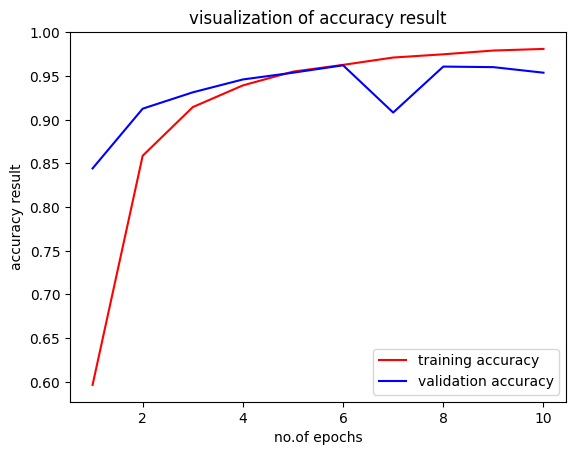

In [57]:
epochs=[i for i in range (1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='training accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='validation accuracy')
plt.xlabel("no.of epochs")
plt.ylabel("accuracy result")
plt.title("visualization of accuracy result")
plt.legend()
plt.show()

some other metrics for model evaluation

In [58]:
class_name=validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [59]:
test_set=tf.keras.utils.image_dataset_from_directory('dataset/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [60]:
y_pred=model.predict(test_set)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 118s 212ms/step


array([[1.0000000e+00, 1.3387257e-10, 2.5292793e-12, ..., 3.0492663e-18,
        1.4322366e-16, 1.3749340e-14],
       [1.0000000e+00, 1.2235921e-13, 5.1248753e-14, ..., 5.2078835e-22,
        9.5572343e-21, 4.3224110e-16],
       [1.0000000e+00, 1.5571278e-14, 4.0804047e-16, ..., 1.3564907e-23,
        1.1476843e-20, 5.2909967e-18],
       ...,
       [9.4295736e-09, 8.2649582e-12, 8.0786180e-08, ..., 3.9777634e-10,
        4.2767984e-10, 9.9999321e-01],
       [8.9792679e-10, 1.2122738e-14, 1.5785513e-10, ..., 1.1155866e-12,
        3.1571124e-12, 1.0000000e+00],
       [3.7916309e-10, 1.1839868e-12, 2.9218853e-11, ..., 6.7898242e-13,
        7.8719413e-11, 9.9999952e-01]], shape=(17572, 38), dtype=float32)

In [61]:
predict_categories=tf.argmax(y_pred,axis=1)
predict_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [62]:
true_categories=tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(17572, 38), dtype=float32)>

In [63]:
Y_true=tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [66]:
from sklearn.metrics import classification_report,confusion_matrix


In [65]:
print(classification_report(Y_true,predict_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.90      0.99      0.94       504
                                 Apple___Black_rot       0.98      0.98      0.98       497
                          Apple___Cedar_apple_rust       0.99      0.91      0.95       440
                                   Apple___healthy       0.97      0.95      0.96       502
                               Blueberry___healthy       0.99      0.96      0.98       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.98      0.99       421
                 Cherry_(including_sour)___healthy       0.99      0.98      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.97      0.87      0.92       410
                       Corn_(maize)___Common_rust_       0.98      1.00      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.93      0.97      0.

In [67]:
cm=confusion_matrix(Y_true,predict_categories)
cm.shape

(38, 38)

confusion matrics visluaization

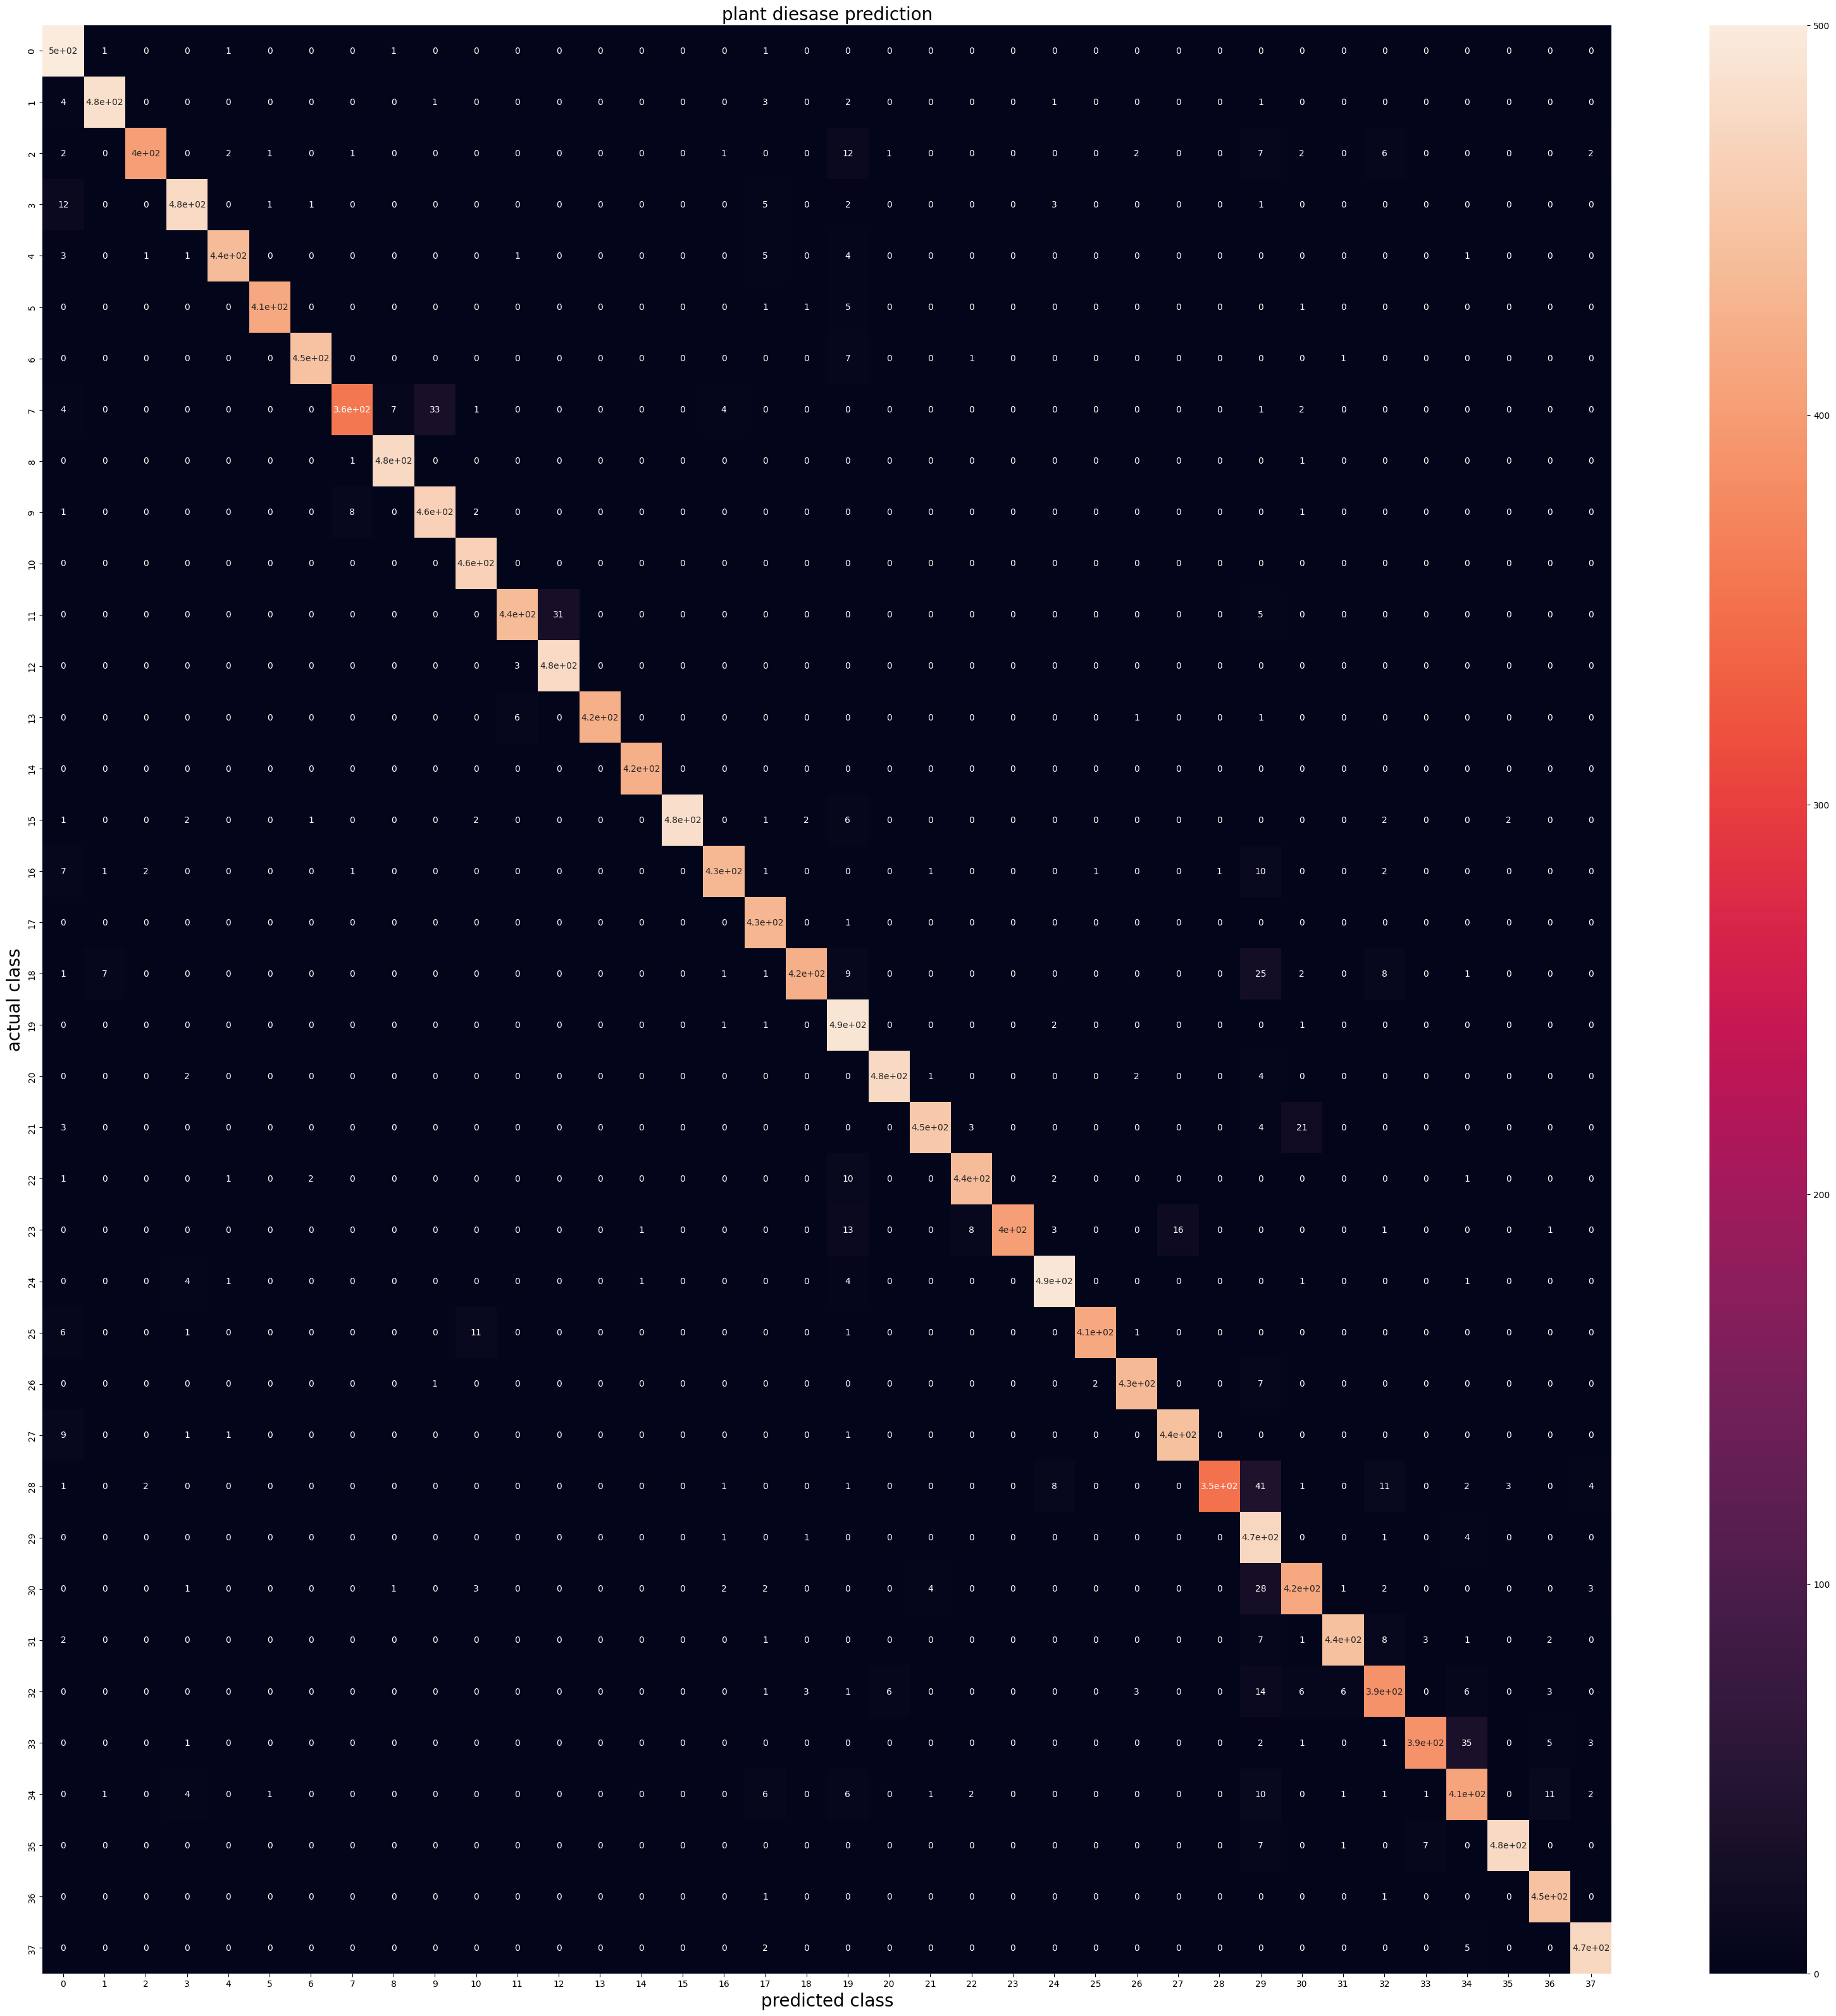

In [79]:
plt.figure(figsize=(40,40))
           
sns.heatmap(cm,annot=True,annot_kws={"size":10})
plt.xlabel("predicted class",fontsize=20)
plt.ylabel("actual class",fontsize=20)
plt.title("plant diesase prediction",fontsize=20)
plt.show()